In [1]:
import numpy as np

data_onehot = np.load("../data/onehot_preds_and_targets.npz")
data_embedding = np.load("../data/emb_preds_and_targets.npz")
p_emb = data_embedding["preds"]
y_emb = data_embedding["targets"]
p_onehot = data_onehot["preds"]
y_onehot = data_onehot["targets"]



In [33]:
total = len(y_emb)
count_class_0 = np.sum(y_emb == 0)
percentage_class_0 = (count_class_0 / total) * 100

print(f"Class 0 count: {count_class_0}")
print(f"Total samples: {total}")
print(f"Percentage of class 0: {percentage_class_0:.2f}%")

Class 0 count: 4694108
Total samples: 5207584
Percentage of class 0: 90.14%


In [2]:

def stratified_random_baseline(y_true, seed=42):
    """
    Create a stratified random baseline: samples class labels randomly
    according to their true class distribution.

    Parameters:
        y_true (np.ndarray): Ground truth labels
        seed (int): Random seed

    Returns:
        y_pred (np.ndarray): Random predictions drawn from class distribution
    """
    np.random.seed(seed)
    unique, counts = np.unique(y_true, return_counts=True)
    probs = counts / counts.sum()
    return np.random.choice(unique, size=len(y_true), p=probs)

# ➕ Use it to get your baseline
p_base = stratified_random_baseline(y_emb)
y_base = y_emb.copy()  # Same targets as embedding model


In [30]:
from sklearn.metrics import f1_score, accuracy_score
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Use full label array (class 0 included)
y_clean = y_emb.copy()
labels_all = np.unique(y_clean)
most_common_nonzero = Counter(y_clean[y_clean != 0]).most_common(1)[0][0]

# 1️⃣ Uniform Random over all labels (including 0)
uniform_random = np.random.choice(labels_all, size=len(y_clean))

# 2️⃣ Always Predict Class 0 (majority class)
always_zero = np.zeros_like(y_clean)

# 3️⃣ Always Predict Most Frequent (non-zero)
always_most_common = np.full_like(y_clean, most_common_nonzero)

# 4️⃣ Stratified Random (custom)
class_counts = Counter(y_clean)
probs_stratified = np.array([class_counts[l] for l in labels_all])
probs_stratified = probs_stratified / probs_stratified.sum()
stratified_random = np.random.choice(labels_all, size=len(y_clean), p=probs_stratified)

# 5️⃣ Frequency Thresholded Random (only sample from common classes)
label_freqs = np.array([class_counts[l] for l in labels_all])
threshold = np.median(label_freqs)
popular_classes = labels_all[label_freqs >= threshold]
thresholded_random = np.random.choice(popular_classes, size=len(y_clean))

# ✅ Evaluation function
def evaluate_baseline(y_true, y_pred):
    return {
        "F1 macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred)
    }

# ✅ Evaluate all baselines
results = {
    "Uniform Random": evaluate_baseline(y_clean, uniform_random),
    "Always Zero": evaluate_baseline(y_clean, always_zero),
    "Always Most-Freq (non-zero)": evaluate_baseline(y_clean, always_most_common),
    "Stratified Random": evaluate_baseline(y_clean, stratified_random),
    "Freq-Threshold Random": evaluate_baseline(y_clean, thresholded_random),
}


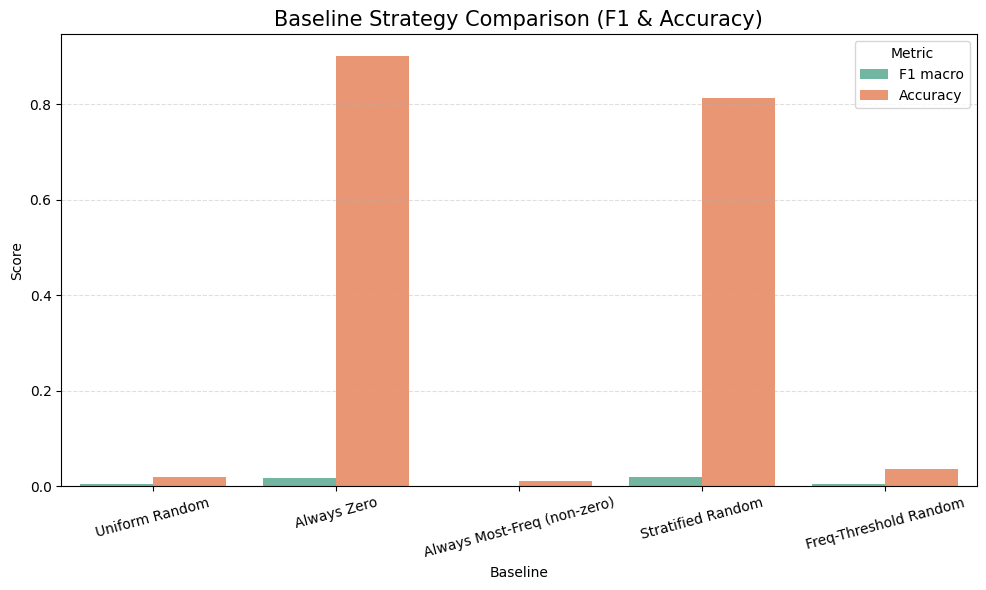

In [31]:
# Format results for seaborn
df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Baseline"})
df_melt = df.melt(id_vars="Baseline", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x="Baseline", y="Score", hue="Metric", palette="Set2")
plt.xticks(rotation=15)
plt.title("Baseline Strategy Comparison (F1 & Accuracy)", fontsize=15)
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("baseline_comparison_thresholded.png", dpi=1000)
plt.show()


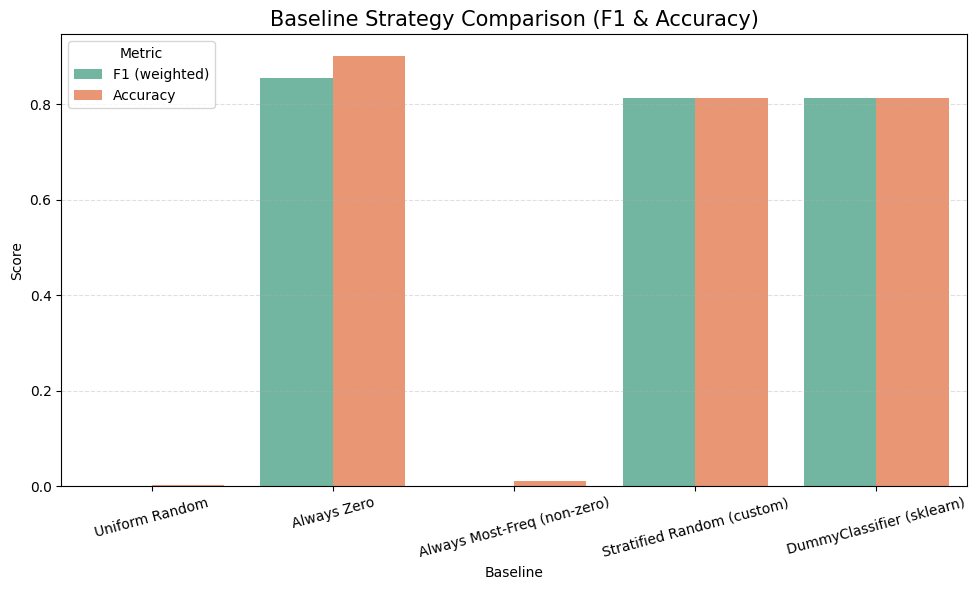

In [25]:
# Format results for seaborn
df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Baseline"})
df_melt = df.melt(id_vars="Baseline", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x="Baseline", y="Score", hue="Metric", palette="Set2")
plt.xticks(rotation=15)
plt.title("Baseline Strategy Comparison (F1 & Accuracy)", fontsize=15)
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("baseline_comparison_strategies.png", dpi=1000)
plt.show()


In [14]:
from sklearn.metrics import f1_score
from tqdm import trange

all_labels = np.unique(np.concatenate([y_emb, y_onehot, y_base]))
n_bootstrap = 500
num_classes = len(all_labels)

f1s_boot_embedding = np.zeros((n_bootstrap, num_classes))
f1s_boot_onehot = np.zeros((n_bootstrap, num_classes))
f1s_boot_baseline = np.zeros((n_bootstrap, num_classes))

for i in trange(n_bootstrap, desc="Bootstrapping"):
    idx_emb = np.random.choice(len(y_emb), size=len(y_emb), replace=True)
    idx_onehot = np.random.choice(len(y_onehot), size=len(y_onehot), replace=True)
    idx_base = np.random.choice(len(y_base), size=len(y_base), replace=True)

    f1s_boot_embedding[i] = f1_score(y_emb[idx_emb], p_emb[idx_emb], average=None, labels=all_labels, zero_division=0)
    f1s_boot_onehot[i] = f1_score(y_onehot[idx_onehot], p_onehot[idx_onehot], average=None, labels=all_labels, zero_division=0)
    f1s_boot_baseline[i] = f1_score(y_base[idx_base], p_base[idx_base], average=None, labels=all_labels, zero_division=0)

def mean_ci(array, ci=95):
    lower = (100 - ci) / 2
    upper = 100 - lower
    return np.nanmean(array, axis=0), np.nanpercentile(array, lower, axis=0), np.nanpercentile(array, upper, axis=0)

mean_f1_emb, low_f1_emb, high_f1_emb = mean_ci(f1s_boot_embedding)
mean_f1_onehot, low_f1_onehot, high_f1_onehot = mean_ci(f1s_boot_onehot)
mean_f1_base, low_f1_base, high_f1_base = mean_ci(f1s_boot_baseline)

# === Print mean ± CI per model ===
print("\n=== Bootstrap Summary (Per-Class F1 Mean ± CI) ===")

mean_ci_error_emb = np.nanmean((high_f1_emb - low_f1_emb) / 2)
print(f"Embedding : {np.nanmean(mean_f1_emb):.4f} ± {mean_ci_error_emb:.4f} "
      f"(95% CI: [{np.nanmean(low_f1_emb):.4f}, {np.nanmean(high_f1_emb):.4f}])")

mean_ci_error_onehot = np.nanmean((high_f1_onehot - low_f1_onehot) / 2)
print(f"One-Hot   : {np.nanmean(mean_f1_onehot):.4f} ± {mean_ci_error_onehot:.4f} "
      f"(95% CI: [{np.nanmean(low_f1_onehot):.4f}, {np.nanmean(high_f1_onehot):.4f}])")

mean_ci_error_base = np.nanmean((high_f1_base - low_f1_base) / 2)
print(f"Baseline  : {np.nanmean(mean_f1_base):.4f} ± {mean_ci_error_base:.4f} "
      f"(95% CI: [{np.nanmean(low_f1_base):.4f}, {np.nanmean(high_f1_base):.4f}])")


Bootstrapping: 100%|██████████| 500/500 [24:30<00:00,  2.94s/it]


=== Bootstrap Summary (Per-Class F1 Mean ± CI) ===
Embedding : 0.6929 ± 0.0060 (95% CI: [0.6867, 0.6988])
One-Hot   : 0.3689 ± 0.0101 (95% CI: [0.3587, 0.3789])
Baseline  : 0.0186 ± 0.0007 (95% CI: [0.0180, 0.0193])


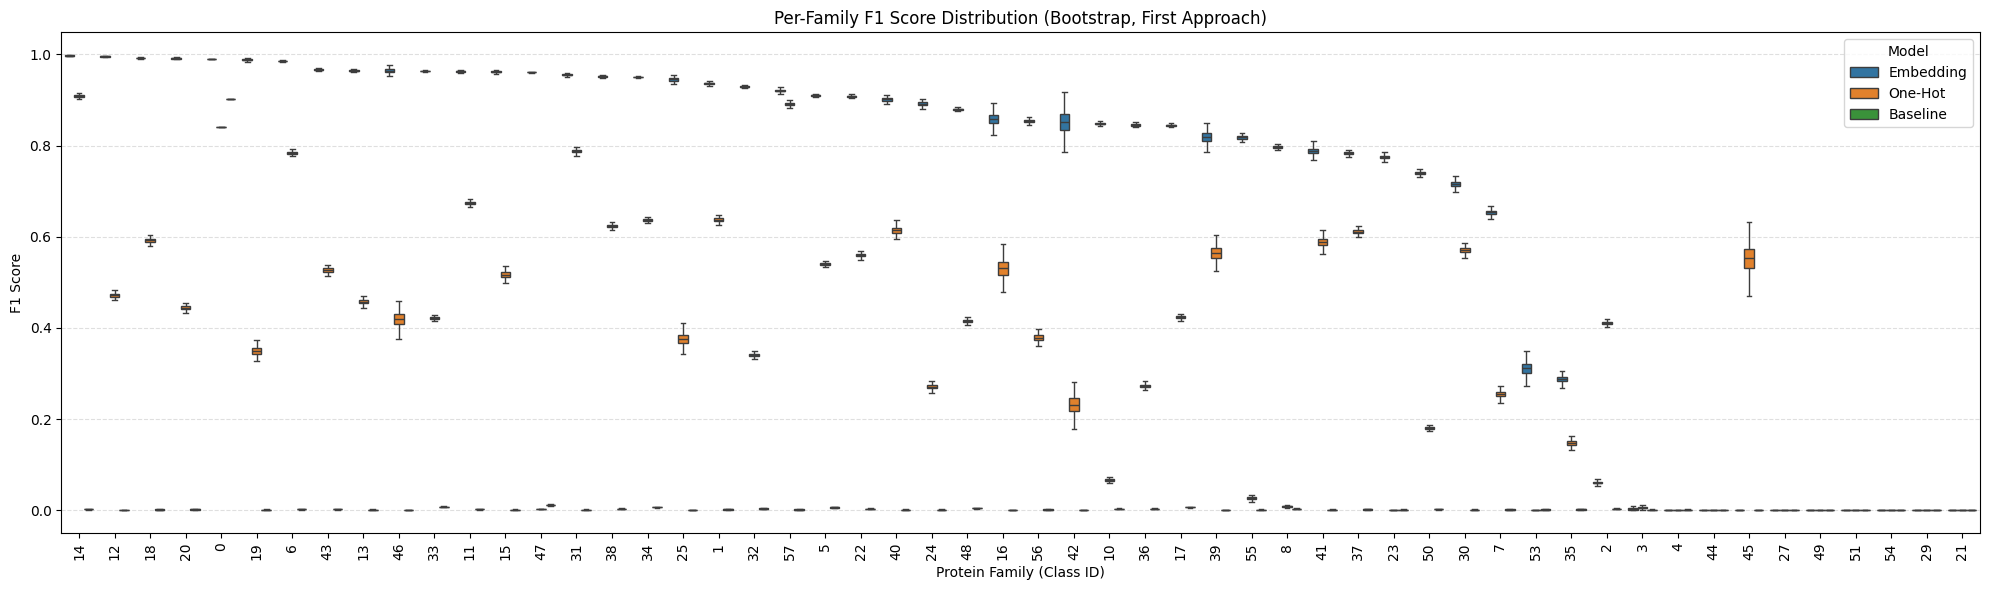

In [20]:
# Transpose: each row becomes a family, columns = bootstraps
df_emb = pd.DataFrame(f1s_boot_embedding.T)
df_onehot = pd.DataFrame(f1s_boot_onehot.T)
df_base = pd.DataFrame(f1s_boot_baseline.T)

# Add family (class) ID as label
df_emb["Family"] = all_labels
df_onehot["Family"] = all_labels
df_base["Family"] = all_labels

# Melt into long format for plotting
df_emb_melt = df_emb.melt(id_vars="Family", var_name="Bootstrap", value_name="F1")
df_emb_melt["Model"] = "Embedding"

df_onehot_melt = df_onehot.melt(id_vars="Family", var_name="Bootstrap", value_name="F1")
df_onehot_melt["Model"] = "One-Hot"

df_base_melt = df_base.melt(id_vars="Family", var_name="Bootstrap", value_name="F1")
df_base_melt["Model"] = "Baseline"

# Combine all into one DataFrame
df_all = pd.concat([df_emb_melt, df_onehot_melt, df_base_melt], axis=0)

# Optional: sort classes by mean F1 of embedding
family_order = df_all[df_all["Model"] == "Embedding"].groupby("Family")["F1"].mean().sort_values(ascending=False).index

# Plot: boxplot per family, colored by model
plt.figure(figsize=(20, 6))
sns.boxplot(data=df_all, x="Family", y="F1", hue="Model", order=family_order, showfliers=False)
plt.xticks(rotation=90)
plt.xlabel("Protein Family (Class ID)")
plt.ylabel("F1 Score")
plt.title("Per-Family F1 Score Distribution (Bootstrap, First Approach)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("per_family_f1_boxplot.png", dpi=1000)
plt.show()


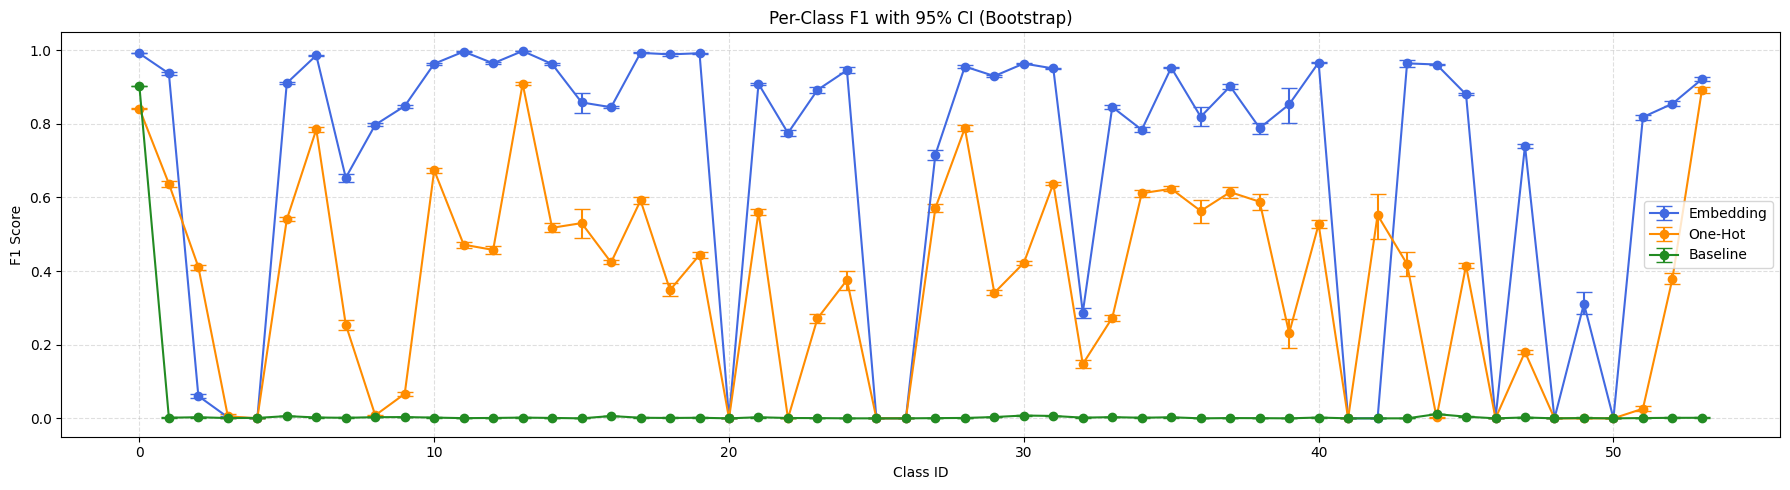

In [19]:
import matplotlib.pyplot as plt

embedding_color = '#4169E1'    # Royal Blue
onehot_color = '#FF8C00'       # Dark Orange
baseline_color = '#228B22' 

x = np.arange(num_classes)
plt.figure(figsize=(18, 5))

plt.errorbar(x, mean_f1_emb, yerr=[mean_f1_emb - low_f1_emb, high_f1_emb - mean_f1_emb], label="Embedding", fmt='-o', capsize=6, color=embedding_color)
plt.errorbar(x, mean_f1_onehot, yerr=[mean_f1_onehot - low_f1_onehot, high_f1_onehot - mean_f1_onehot], label="One-Hot", fmt='-o', capsize=6, color=onehot_color)
plt.errorbar(x, mean_f1_base, yerr=[mean_f1_base - low_f1_base, high_f1_base - mean_f1_base], label="Baseline", fmt='-o', capsize=6, color=baseline_color)

plt.xlabel("Class ID")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 with 95% CI (Bootstrap)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("per_class_boot.png", dpi=1000)
plt.show()


Top 10 predicted classes (embedding): [0, 47, 33, 5, 34, 17, 48, 8, 32, 50]


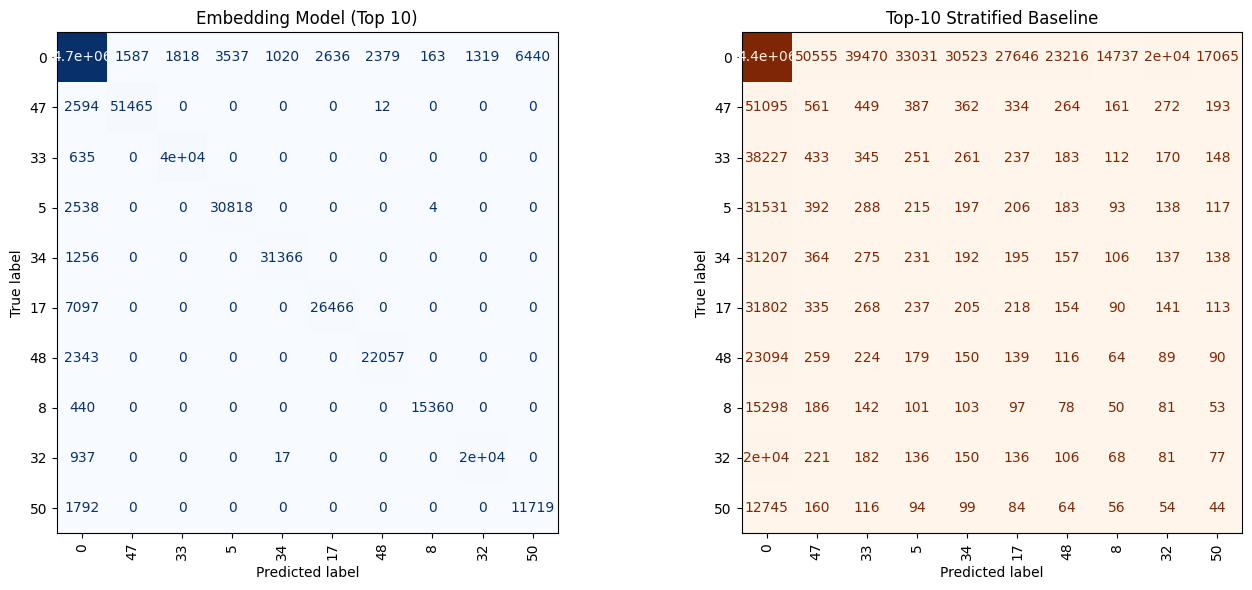

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

# 1️⃣ Get top 10 most frequent predicted classes from embedding
top10_classes = [cls for cls, _ in Counter(p_emb).most_common(10)]
print("Top 10 predicted classes (embedding):", top10_classes)

# 2️⃣ Filter y_emb and pred_emb to only those classes
mask_top10 = np.isin(y_emb, top10_classes)
y_top10 = y_emb[mask_top10]
p_emb_top10 = p_emb[mask_top10]

# 3️⃣ Build baseline: sample from top-10 using their proportions
counts = Counter(p_emb_top10)
total = sum(counts[c] for c in top10_classes)
probs = np.array([counts[c] / total for c in top10_classes])
p_base_top10 = np.random.choice(top10_classes, size=len(y_top10), p=probs)

# 4️⃣ Confusion Matrices
cm_emb = confusion_matrix(y_top10, p_emb_top10, labels=top10_classes)
cm_base = confusion_matrix(y_top10, p_base_top10, labels=top10_classes)

# 5️⃣ Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(cm_emb, display_labels=top10_classes).plot(ax=axes[0], xticks_rotation=90, cmap="Blues", colorbar=False)
axes[0].set_title("Embedding Model (Top 10)")

ConfusionMatrixDisplay(cm_base, display_labels=top10_classes).plot(ax=axes[1], xticks_rotation=90, cmap="Oranges", colorbar=False)
axes[1].set_title("Top-10 Stratified Baseline")

plt.tight_layout()
plt.show()


Top 10 non-zero predicted classes (embedding): [47, 33, 34, 5, 17, 48, 8, 32, 38, 10]


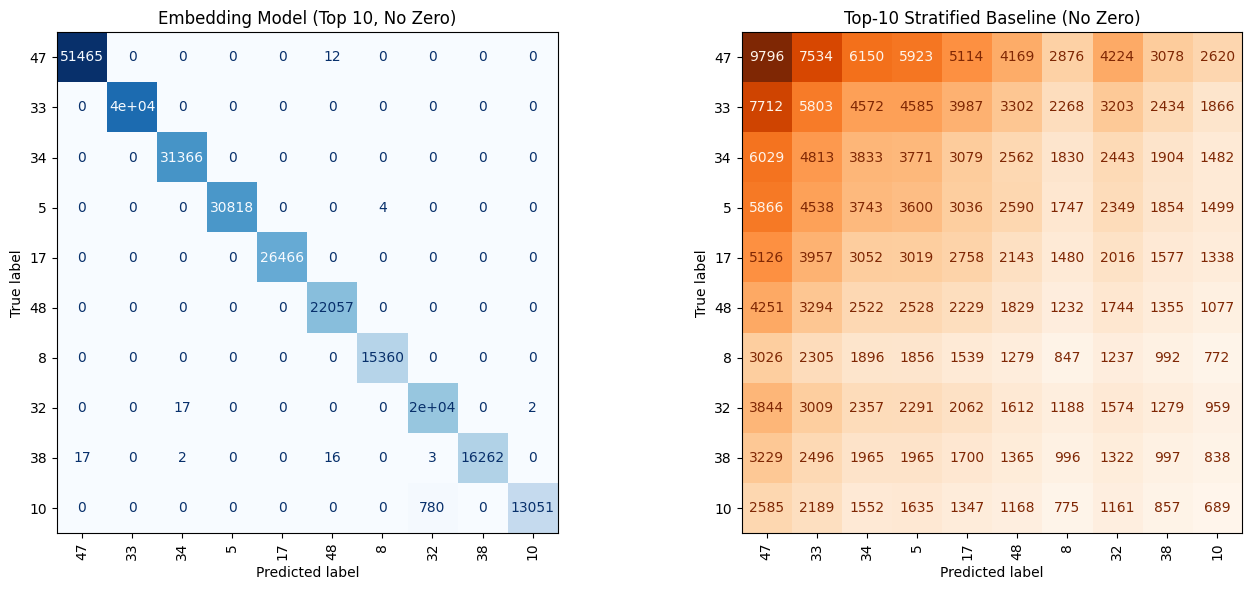

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

# Step 1: Mask out class 0 from y_emb and pred_emb
mask_nonzero = (y_emb != 0) & (p_emb != 0)
y_nz = y_emb[mask_nonzero]
p_emb_nz = p_emb[mask_nonzero]

# Step 2: Get top 10 most frequent predicted classes (excluding 0)
top10_classes = [cls for cls, _ in Counter(p_emb_nz).most_common(10)]
print("Top 10 non-zero predicted classes (embedding):", top10_classes)

# Step 3: Filter to only those top-10 classes in both y and pred
mask_top10 = np.isin(y_nz, top10_classes)
y_top10 = y_nz[mask_top10]
p_emb_top10 = p_emb_nz[mask_top10]

# Step 4: Stratified baseline from predicted class distribution (top10)
counts = Counter(p_emb_top10)
total = sum(counts[c] for c in top10_classes)
probs = np.array([counts[c] / total for c in top10_classes])
p_base_top10 = np.random.choice(top10_classes, size=len(y_top10), p=probs)

# Step 5: Compute confusion matrices
cm_emb = confusion_matrix(y_top10, p_emb_top10, labels=top10_classes)
cm_base = confusion_matrix(y_top10, p_base_top10, labels=top10_classes)

# Step 6: Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(cm_emb, display_labels=top10_classes).plot(ax=axes[0], xticks_rotation=90, cmap="Blues", colorbar=False)
axes[0].set_title("Embedding Model (Top 10, No Zero)")

ConfusionMatrixDisplay(cm_base, display_labels=top10_classes).plot(ax=axes[1], xticks_rotation=90, cmap="Oranges", colorbar=False)
axes[1].set_title("Top-10 Stratified Baseline (No Zero)")

plt.tight_layout()
plt.show()


In [16]:
from sklearn.metrics import matthews_corrcoef, f1_score

def bootstrap_metrics(y_true, y_pred, metric_fns, n_bootstrap=500):
    results = {name: [] for name in metric_fns}
    for _ in trange(n_bootstrap, leave=False):
        idx = np.random.choice(len(y_true), len(y_true), replace=True)
        y_sample = y_true[idx]
        p_sample = y_pred[idx]
        for name, fn in metric_fns.items():
            try:
                score = fn(y_sample, p_sample)
            except:
                score = np.nan
            results[name].append(score)
    summary = {
        name: (
            np.nanmean(vals),
            np.nanpercentile(vals, 2.5),
            np.nanpercentile(vals, 97.5)
        )
        for name, vals in results.items()
    }
    return summary, results

metric_fns = {
    "Weighted F1": lambda y, p: f1_score(y, p, average="macro", zero_division=0),
    "MCC": matthews_corrcoef
}

results_emb, scores_emb = bootstrap_metrics(y_emb, p_emb, metric_fns)
results_one, scores_one = bootstrap_metrics(y_onehot, p_onehot, metric_fns)
results_base, scores_base = bootstrap_metrics(y_base, p_base, metric_fns)

# === Print results ===
print("\n=== Bootstrap Summary (Overall Metrics ± CI) ===")
for name, result in zip(["Embedding", "One-Hot", "Baseline"],
                        [results_emb, results_one, results_base]):
    print(f"\n--- {name} ---")
    for metric in metric_fns:
        mean, low, high = result[metric]
        print(f"{metric:12s}: {mean:.4f} ± {high - mean:.4f} (95% CI: [{low:.4f}, {high:.4f}])")



=== Bootstrap Summary (Overall Metrics ± CI) ===

--- Embedding ---
Weighted F1 : 0.6681 ± 0.0014 (95% CI: [0.6665, 0.6695])
MCC         : 0.8904 ± 0.0006 (95% CI: [0.8898, 0.8910])

--- One-Hot ---
Weighted F1 : 0.3558 ± 0.0019 (95% CI: [0.3538, 0.3576])
MCC         : 0.4241 ± 0.0012 (95% CI: [0.4229, 0.4253])

--- Baseline ---
Weighted F1 : 0.0185 ± 0.0001 (95% CI: [0.0184, 0.0187])
MCC         : -0.0002 ± 0.0004 (95% CI: [-0.0006, 0.0003])


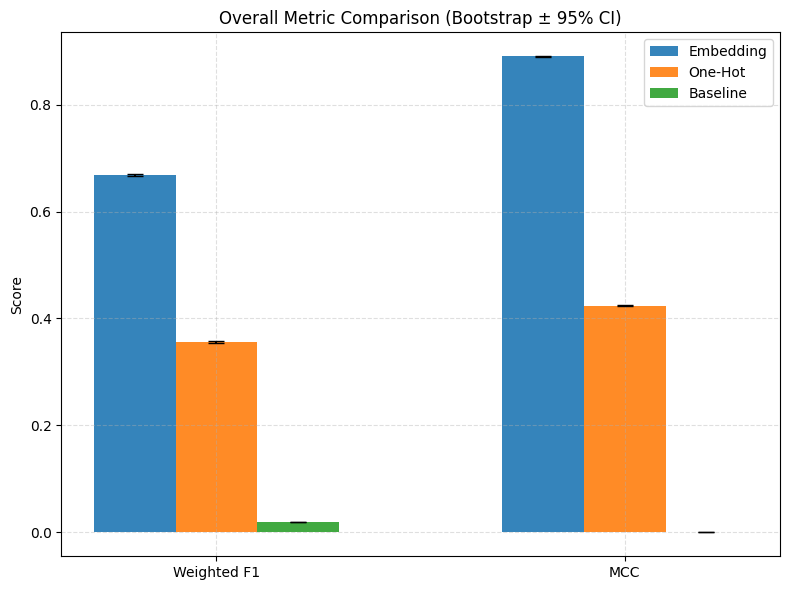

In [17]:
models = ["Embedding", "One-Hot", "Baseline"]
metrics = list(metric_fns.keys())

scores = []
errors_lower = []
errors_upper = []

for metric in metrics:
    row = []
    lo = []
    hi = []
    for res in [results_emb, results_one, results_base]:
        mean, low, high = res[metric]
        row.append(mean)
        lo.append(mean - low)
        hi.append(high - mean)
    scores.append(row)
    errors_lower.append(lo)
    errors_upper.append(hi)

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 6))
for i, model in enumerate(models):
    ax.bar(x + (i - 1) * width,
           [scores[j][i] for j in range(len(metrics))],
           width,
           yerr=[[errors_lower[j][i] for j in range(len(metrics))],
                 [errors_upper[j][i] for j in range(len(metrics))]],
           capsize=6,
           label=model,
           alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Overall Metric Comparison (Bootstrap ± 95% CI)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("overall_boot.png", dpi=1000)
plt.show()


/var/folders/db/dsvhqmgs43ndkl9342nsk7_00000gn/T/ipykernel_51224/1515199159.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="Model", y="Score", palette="Set2")


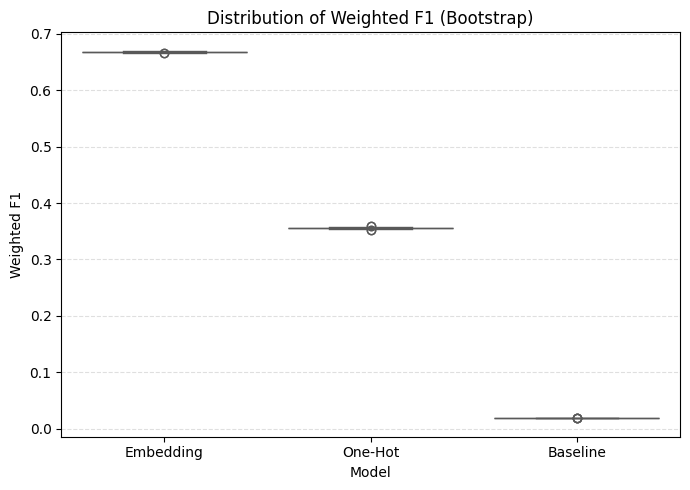

In [18]:
import pandas as pd
import seaborn as sns

def prepare_box_data(metric_name):
    return pd.DataFrame({
        "Model": ["Embedding"] * len(scores_emb[metric_name]) +
                 ["One-Hot"] * len(scores_one[metric_name]) +
                 ["Baseline"] * len(scores_base[metric_name]),
        "Score": scores_emb[metric_name] + scores_one[metric_name] + scores_base[metric_name]
    })

plt.figure(figsize=(7, 5))
df_box = prepare_box_data("Weighted F1")
sns.boxplot(data=df_box, x="Model", y="Score", palette="Set2")
plt.title("Distribution of Weighted F1 (Bootstrap)")
plt.ylabel("Weighted F1")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
